# Setup

In [1]:
# ─────────────────────────────────────────────
# 06_finetuning_attempt.ipynb
#
# Purpose:
#   Attempt to fine-tune the ms-marco cross-encoder
#   on MedMCQA question-explanation pairs.
#   Documents both the attempt and the failure.
#
#   Attempt 1 — Random negatives (documented failure):
#     Positive: question + its own explanation
#     Negative: question + random wrong explanation
#     Result:   accuracy dropped to ~34%
#     Cause:    catastrophic forgetting + easy negatives
#
#   Attempt 2 — Hard negatives (corrected approach):
#     Positive: question + its own explanation
#     Negative: question + FAISS-retrieved wrong explanation
#     Mixed:    70% medical pairs + 30% general pairs
#     LR:       5e-6 (4x smaller than default)
#     Result:   documented here
#
# Inputs:
#   data/cleaned_kb_docs.pkl
#   data/train_qa.pkl
#   data/kb_index_cleaned.faiss
#   data/val_eval_mcq.pkl
#   data/val_tune_mcq.pkl
#
# Outputs:
#   models/ce_finetuned_attempt1/  (if run)
#   models/ce_finetuned_attempt2/  (corrected)
#   results/finetuning_results.json
# ─────────────────────────────────────────────

!pip install faiss-cpu sentence-transformers \
             rank-bm25 transformers torch -q

import os
import sys
import json
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
from sentence_transformers import CrossEncoder, InputExample
from sentence_transformers.cross_encoder.evaluation import (
    CEBinaryAccuracyEvaluator
)
from google.colab import drive
import torch

drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/MedQA_Project"
sys.path.insert(0, BASE)

from src.config import (
    DATA_DIR, RESULTS_DIR, MODELS_DIR, ensure_dirs,
    CLEANED_KB_PATH, FAISS_INDEX_PATH, INDEX_CONFIG_PATH,
    VAL_EVAL_MCQ_PATH, VAL_TUNE_MCQ_PATH,
    TRAIN_QA_PATH, CE_BASE_MODEL, CRAG_CONFIG_PATH,
    FT_LEARNING_RATE, FT_EPOCHS, FT_BATCH_SIZE,
    FT_MAX_PAIRS,
)
from src.data_processing import load_pkl
from src.knowledge_base import load_faiss_index, load_bm25_index
from src.models import load_retriever, load_cross_encoder
from src.mcq_pipeline import crag_pipeline
from src.evaluation import (
    evaluate_pipeline, save_results,
    compute_faithfulness, compute_ece,
)

ensure_dirs()

BM25_INDEX_PATH = f"{DATA_DIR}/bm25_index.pkl"
FT_A1_PATH      = f"{MODELS_DIR}/ce_finetuned_attempt1"
FT_A2_PATH      = f"{MODELS_DIR}/ce_finetuned_attempt2"
FT_RESULTS_PATH = f"{RESULTS_DIR}/finetuning_results.json"

random.seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

print("Setup complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 83.9 MB/s eta 0:00:00
Mounted at /content/drive
Using device: cuda
Setup complete


#  Load artifacts

In [2]:
# ─────────────────────────────────────────────
# Load all required artifacts
# ─────────────────────────────────────────────

cleaned_kb_docs = load_pkl(CLEANED_KB_PATH,  "cleaned_kb_docs")
train_qa        = load_pkl(TRAIN_QA_PATH,    "train_qa")
val_eval_mcq    = load_pkl(VAL_EVAL_MCQ_PATH, "val_eval_mcq")
val_tune_mcq    = load_pkl(VAL_TUNE_MCQ_PATH, "val_tune_mcq")

faiss_index, index_config = load_faiss_index()
bm25_index                = load_bm25_index(BM25_INDEX_PATH)
retriever                  = load_retriever()

# Build lookups
kb_id_lookup = {doc['id']: (i, doc)
                 for i, doc in enumerate(cleaned_kb_docs)}
kb_texts     = [doc['text'] for doc in cleaned_kb_docs]

# Load optimal tau
with open(CRAG_CONFIG_PATH, "rb") as f:
    crag_config = pickle.load(f)
optimal_tau = crag_config['optimal_tau']

# Load reference accuracy (CRAG v3 with base CE)
with open(f"{RESULTS_DIR}/crag_v3.json") as f:
    reference_acc = json.load(f)['accuracy']

print(f"\nAll artifacts loaded")
print(f"  KB docs:        {len(cleaned_kb_docs):,}")
print(f"  Train QA:       {len(train_qa):,}")
print(f"  Val eval MCQ:   {len(val_eval_mcq):,}")
print(f"  Reference acc:  {reference_acc:.2f}%")
print(f"  Optimal tau:    {optimal_tau}")

  Loaded cleaned_kb_docs
  Loaded train_qa
  Loaded val_eval_mcq
  Loaded val_tune_mcq
FAISS index loaded:
  Vectors: 156,555
  nprobe:  50
  Trained: True
  BM25 index loaded: 290,428 terms
Loading retriever: sentence-transformers/all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Parameters: ~22M  |  Output dim: 384

All artifacts loaded
  KB docs:        156,555
  Train QA:       182,822
  Val eval MCQ:   2,092
  Reference acc:  40.01%
  Optimal tau:    0.5


# Build training data: valid pairs

In [3]:
# ─────────────────────────────────────────────
# Build positive training pairs
#
# Positive pair: question matched with its own
# explanation (the document it came from).
# Label = 1.0 (highly relevant)
#
# Only questions that have a matching KB doc
# can form positive pairs.
# ─────────────────────────────────────────────

print("Building positive training pairs...\n")

valid_train = [
    qa for qa in train_qa
    if qa['id'] in kb_id_lookup
]

print(f"Training QA with KB doc: {len(valid_train):,}")
print(f"  (out of {len(train_qa):,} total train QA)")

# Show distribution of valid pairs per subject
from collections import Counter
subj_counts = Counter(qa['subject'] for qa in valid_train)
print(f"\nTop subjects in valid training pairs:")
for subj, cnt in subj_counts.most_common(5):
    print(f"  {subj:<35} {cnt:,}")

Building positive training pairs...

Training QA with KB doc: 154,361
  (out of 182,822 total train QA)

Top subjects in valid training pairs:
  Medicine                            14,465
  Surgery                             14,199
  Anatomy                             13,399
  Pathology                           12,450
  Pharmacology                        10,962


# Attempt 1: Random negatives

In [4]:
# ─────────────────────────────────────────────
# ATTEMPT 1 — Random negatives
#
# This is the approach that FAILED.
# Documented here so the failure is explicit
# and the reasoning is clear.
#
# Problem 1 — Easy negatives:
#   Random wrong-topic passages are trivially
#   distinguishable. The model learns nothing
#   about fine-grained medical relevance.
#   Example: TB question + Diabetes passage
#   → obviously irrelevant, no learning signal
#
# Problem 2 — Catastrophic forgetting:
#   Training only on medical pairs overwrites
#   the model's general relevance capability.
#   Without mixed-domain data, the model
#   forgets how to score non-medical relevance.
#
# We run this only if the attempt1 model does
# not already exist, to avoid wasting time.
# ─────────────────────────────────────────────

print("ATTEMPT 1 — Random negatives (documented failure)\n")

FT_A1_EVAL_PATH = f"{RESULTS_DIR}/ft_attempt1_eval.json"

if os.path.exists(FT_A1_EVAL_PATH):
    print("Attempt 1 results already exist — loading")
    with open(FT_A1_EVAL_PATH) as f:
        a1_data = json.load(f)
    a1_acc = a1_data['accuracy']
    print(f"Attempt 1 accuracy: {a1_acc:.2f}%")
    print(f"Reference (base CE): {reference_acc:.2f}%")
    print(f"Drop: {a1_acc - reference_acc:+.2f}%")

else:
    print("Building random negative pairs...")

    # Positive pairs
    a1_examples = []
    n_kb = len(cleaned_kb_docs)

    for qa in valid_train[:FT_MAX_PAIRS // 2]:
        idx, doc = kb_id_lookup[qa['id']]

        # Positive
        a1_examples.append(InputExample(
            texts=[qa['question'], doc['text']],
            label=1.0
        ))

        # Random negative — different document
        neg_idx = random.randint(0, n_kb - 1)
        while neg_idx == idx:
            neg_idx = random.randint(0, n_kb - 1)

        a1_examples.append(InputExample(
            texts=[qa['question'], kb_texts[neg_idx]],
            label=0.0
        ))

    random.shuffle(a1_examples)
    print(f"Pairs built: {len(a1_examples):,}")
    print(f"  Positive: {len(a1_examples)//2:,}")
    print(f"  Negative: {len(a1_examples)//2:,}")

    # Build evaluator from val_tune
    eval_pairs  = []
    eval_labels = []
    for qa in val_tune_mcq[:300]:
        if qa['id'] in kb_id_lookup:
            idx, doc = kb_id_lookup[qa['id']]
            eval_pairs.append(
                (qa['question'], doc['text']))
            eval_labels.append(1)
            neg_idx = random.randint(0, n_kb - 1)
            while neg_idx == idx:
                neg_idx = random.randint(0, n_kb - 1)
            eval_pairs.append(
                (qa['question'], kb_texts[neg_idx]))
            eval_labels.append(0)

    evaluator = CEBinaryAccuracyEvaluator(
        sentence_pairs=eval_pairs,
        labels=eval_labels,
        name="medmcqa_val_a1",
    )

    # Train attempt 1
    print(f"\nTraining attempt 1...")
    print(f"  Pairs:  {len(a1_examples):,}")
    print(f"  Epochs: {FT_EPOCHS}")
    print(f"  LR:     2e-5 (default — this is the problem)")
    print(f"  Batch:  {FT_BATCH_SIZE}")

    os.makedirs(FT_A1_PATH, exist_ok=True)
    ft_model_a1 = CrossEncoder(
        CE_BASE_MODEL, num_labels=1, max_length=512, device=device)

    ft_model_a1.fit(
        train_dataloader=DataLoader(
            a1_examples, shuffle=True,
            batch_size=FT_BATCH_SIZE),
        evaluator=evaluator,
        epochs=FT_EPOCHS,
        warmup_steps=200,
        output_path=FT_A1_PATH,
        save_best_model=True,
        show_progress_bar=True,
        evaluation_steps=500,
    )

    # Evaluate
    print("\nEvaluating attempt 1 on val_eval_mcq...")
    ft_a1_loaded = CrossEncoder(FT_A1_PATH, max_length=512, device=device)
    a1_eval = evaluate_pipeline(
        val_eval_mcq,
        lambda q, opts: crag_pipeline(
            q, opts, faiss_index, bm25_index,
            cleaned_kb_docs, retriever,
            ft_a1_loaded, tau=optimal_tau),
        desc="FT Attempt 1",
    )
    a1_acc = a1_eval['accuracy']

    a1_data = {
        "attempt":      1,
        "strategy":     "random_negatives",
        "lr":           "2e-5 (default)",
        "n_pairs":      len(a1_examples),
        "accuracy":     a1_acc,
        "reference":    reference_acc,
        "drop":         round(a1_acc - reference_acc, 2),
        "failure_reasons": [
            "Easy negatives: randomly sampled wrong-topic "
            "passages are trivially distinguishable — "
            "no fine-grained medical learning occurs",
            "Catastrophic forgetting: training on narrow "
            "medical distribution overwrites general "
            "relevance scoring capability"
        ],
    }
    save_results(a1_data, FT_A1_EVAL_PATH, "ft_attempt1")

    print(f"\nAttempt 1 accuracy:  {a1_acc:.2f}%")
    print(f"Reference (base CE): {reference_acc:.2f}%")
    print(f"Drop:                {a1_acc-reference_acc:+.2f}%")
    print(f"\nConclusion: fine-tuning FAILED with random negatives")

ATTEMPT 1 — Random negatives (documented failure)

Building random negative pairs...
Pairs built: 60,000
  Positive: 30,000
  Negative: 30,000

Training attempt 1...
  Pairs:  60,000
  Epochs: 1
  LR:     2e-5 (default — this is the problem)
  Batch:  32


/tmp/ipykernel_2245/1416852468.py:85: DeprecationWarning: This evaluator has been deprecated in favor of the more general CrossEncoderClassificationEvaluator. Please use CrossEncoderClassificationEvaluator instead, which supports both binary and multi-class evaluation. It accepts approximately the same inputs as this evaluator.
  evaluator = CEBinaryAccuracyEvaluator(


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating attempt 1 on val_eval_mcq...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

FT Attempt 1: 100%|██████████| 2092/2092 [02:20<00:00, 14.94it/s]

  Saved ft_attempt1: 0.5 KB

Attempt 1 accuracy:  37.52%
Reference (base CE): 40.01%
Drop:                -2.49%

Conclusion: fine-tuning FAILED with random negatives


#  Build hard negatives

In [5]:
# ─────────────────────────────────────────────
# Hard negatives for Attempt 2
#
# Hard negatives are passages retrieved by FAISS
# for a question that belong to a DIFFERENT
# question's explanation.
#
# These are genuinely confusing cases:
#   - Same medical domain
#   - Semantically similar to the question
#   - But NOT the correct explanation
#
# Training on hard negatives forces the model
# to learn fine-grained medical distinctions.
# ─────────────────────────────────────────────

print("Building hard negative pairs for Attempt 2...\n")

HARD_NEG_PATH = f"{DATA_DIR}/hard_neg_examples.pkl"

if os.path.exists(HARD_NEG_PATH):
    print("Hard negatives already built — loading")
    with open(HARD_NEG_PATH, "rb") as f:
        hard_neg_examples = pickle.load(f)
    print(f"Hard neg pairs: {len(hard_neg_examples):,}")

else:
    print("Generating hard negatives using FAISS retrieval...")
    print("This finds passages that LOOK relevant but are WRONG\n")

    sample_size = min(20000, len(valid_train))
    sampled     = random.sample(valid_train, sample_size)

    # Embed all questions at once for efficiency
    q_texts = [qa['question'] for qa in sampled]
    print(f"Embedding {len(q_texts):,} questions...")
    q_embs  = retriever.encode(
        q_texts,
        batch_size=256,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=True,
    )

    # Retrieve top-5 for each question
    print("Retrieving top-5 FAISS passages...")
    distances, indices = faiss_index.search(
        q_embs.astype(np.float32), 5)

    hard_neg_examples = []

    for i, qa in enumerate(tqdm(sampled,
                                 desc="Building pairs")):
        if qa['id'] not in kb_id_lookup:
            continue

        correct_idx, correct_doc = kb_id_lookup[qa['id']]

        # Positive pair
        hard_neg_examples.append(InputExample(
            texts=[qa['question'], correct_doc['text']],
            label=1.0
        ))

        # Hard negative — FAISS retrieved but wrong
        for rank in range(5):
            ret_idx = int(indices[i][rank])
            if ret_idx == -1:
                continue
            ret_doc = cleaned_kb_docs[ret_idx]
            if ret_doc['id'] != qa['id']:
                hard_neg_examples.append(InputExample(
                    texts=[qa['question'], ret_doc['text']],
                    label=0.0
                ))
                break

    with open(HARD_NEG_PATH, "wb") as f:
        pickle.dump(hard_neg_examples, f)

    print(f"\nHard negative pairs built: {len(hard_neg_examples):,}")
    pos = sum(1 for e in hard_neg_examples if e.label == 1.0)
    neg = len(hard_neg_examples) - pos
    print(f"  Positive: {pos:,}")
    print(f"  Hard neg: {neg:,}")

    size_mb = os.path.getsize(HARD_NEG_PATH)/(1024**2)
    print(f"  Saved: {size_mb:.1f} MB")

Building hard negative pairs for Attempt 2...

Hard negatives already built — loading
Hard neg pairs: 40,000


#  Build mixed training data

In [6]:
# ─────────────────────────────────────────────
# Mixed training data for Attempt 2
#
# Mix: 70% hard negative medical pairs
#      30% general relevance pairs
#
# The general pairs preserve the model's base
# relevance scoring capability and prevent
# catastrophic forgetting.
#
# General pairs: built from KB docs themselves
# First sentence of doc as query → full doc as passage
# This mimics general passage relevance training
# without requiring external datasets.
# ─────────────────────────────────────────────

print("Building mixed training data...\n")

# Limit hard neg pairs
n_hard = min(len(hard_neg_examples), FT_MAX_PAIRS)
medical_pairs = random.sample(hard_neg_examples, n_hard)

# General pairs (30% of medical count)
n_general = int(n_hard * 0.30)
general_pairs = []
n_kb = len(cleaned_kb_docs)

for _ in range(n_general // 2):
    # Positive general pair
    idx1 = random.randint(0, n_kb - 1)
    doc1 = cleaned_kb_docs[idx1]
    sentences = [s.strip() for s in
                  doc1['text'].split('.')
                  if len(s.strip()) > 20]
    if not sentences:
        continue
    query = sentences[0]

    general_pairs.append(InputExample(
        texts=[query, doc1['text']],
        label=1.0
    ))

    # Negative general pair
    idx2 = random.randint(0, n_kb - 1)
    while idx2 == idx1:
        idx2 = random.randint(0, n_kb - 1)

    general_pairs.append(InputExample(
        texts=[query, cleaned_kb_docs[idx2]['text']],
        label=0.0
    ))

# Combine and shuffle
mixed_examples = medical_pairs + general_pairs
random.shuffle(mixed_examples)

pos_count = sum(1 for e in mixed_examples if e.label == 1.0)
neg_count = len(mixed_examples) - pos_count

print(f"Mixed training set:")
print(f"  Total pairs:     {len(mixed_examples):,}")
print(f"  Medical hard:    {len(medical_pairs):,} "
      f"({len(medical_pairs)/len(mixed_examples)*100:.0f}%)")
print(f"  General:         {len(general_pairs):,} "
      f"({len(general_pairs)/len(mixed_examples)*100:.0f}%)")
print(f"  Positive:        {pos_count:,}")
print(f"  Negative:        {neg_count:,}")

Building mixed training data...

Mixed training set:
  Total pairs:     51,398
  Medical hard:    40,000 (78%)
  General:         11,398 (22%)
  Positive:        25,699
  Negative:        25,699


# Build evaluator for Attempt 2

In [7]:
# ─────────────────────────────────────────────
# Build evaluator using val_tune
# Monitors training progress every 500 steps
# Saves best checkpoint automatically
# ─────────────────────────────────────────────

print("Building validation evaluator...\n")

eval_pairs  = []
eval_labels = []
n_kb = len(cleaned_kb_docs)

for qa in val_tune_mcq[:500]:
    if qa['id'] not in kb_id_lookup:
        continue

    idx, doc = kb_id_lookup[qa['id']]

    # Positive: question + its own explanation
    eval_pairs.append((qa['question'], doc['text']))
    eval_labels.append(1)

    # Hard negative: FAISS-retrieved wrong passage
    from src.retriever import retrieve_faiss
    passages = retrieve_faiss(
        qa['question'], faiss_index,
        cleaned_kb_docs, retriever, top_k=5)

    hard_neg_text = None
    for p in passages:
        if p['doc_idx'] != idx:
            hard_neg_text = p['text']
            break

    if hard_neg_text:
        eval_pairs.append((qa['question'], hard_neg_text))
        eval_labels.append(0)

evaluator_a2 = CEBinaryAccuracyEvaluator(
    sentence_pairs=eval_pairs,
    labels=eval_labels,
    name="medmcqa_val_a2",
)

print(f"Evaluator built:")
print(f"  Pairs:    {len(eval_pairs):,}")
print(f"  Positive: {sum(eval_labels):,}")
print(f"  Negative: {len(eval_labels)-sum(eval_labels):,}")

Building validation evaluator...

Evaluator built:
  Pairs:    540
  Positive: 270
  Negative: 270


/tmp/ipykernel_2245/2893735643.py:39: DeprecationWarning: This evaluator has been deprecated in favor of the more general CrossEncoderClassificationEvaluator. Please use CrossEncoderClassificationEvaluator instead, which supports both binary and multi-class evaluation. It accepts approximately the same inputs as this evaluator.
  evaluator_a2 = CEBinaryAccuracyEvaluator(


# Attempt 2: Hard negatives + mixed data

In [8]:
# ─────────────────────────────────────────────
# ATTEMPT 2 — Corrected fine-tuning
#
# Changes from Attempt 1:
#   Hard negatives (not random)
#   Mixed domain data (prevents forgetting)
#   Lower learning rate: 5e-6 (was 2e-5)
#   1 epoch only (was 2)
# ─────────────────────────────────────────────

FT_A2_EVAL_PATH = f"{RESULTS_DIR}/ft_attempt2_eval.json"

if os.path.exists(FT_A2_EVAL_PATH):
    print("Attempt 2 results already exist — loading\n")
    with open(FT_A2_EVAL_PATH) as f:
        a2_data = json.load(f)
    a2_acc = a2_data['accuracy']

else:
    print("ATTEMPT 2 — Hard negatives + mixed data\n")
    print(f"  Pairs:  {len(mixed_examples):,}")
    print(f"  Epochs: 1")
    print(f"  LR:     {FT_LEARNING_RATE} (4x smaller)")
    print(f"  Batch:  {FT_BATCH_SIZE}\n")

    os.makedirs(FT_A2_PATH, exist_ok=True)

    ft_model_a2 = CrossEncoder(
        CE_BASE_MODEL, num_labels=1, max_length=512, device=device)

    ft_model_a2.fit(
        train_dataloader=DataLoader(
            mixed_examples, shuffle=True,
            batch_size=FT_BATCH_SIZE),
        evaluator=evaluator_a2,
        epochs=1,
        warmup_steps=300,
        optimizer_params={'lr': FT_LEARNING_RATE},
        output_path=FT_A2_PATH,
        save_best_model=True,
        show_progress_bar=True,
        evaluation_steps=500,
    )

    # Quick score test before full eval
    print("\nScore test on known pairs:")
    test_pos_pairs = [
        ("Drug of choice for TB?",
         "RIPE therapy is the first line treatment "
         "for Tuberculosis."),
    ]
    test_neg_pairs = [
        ("Drug of choice for TB?",
         "Metformin is used for Type 2 Diabetes."),
    ]

    ft_a2_loaded = CrossEncoder(FT_A2_PATH, max_length=512, device=device)
    pos_score = float(
        ft_a2_loaded.predict(test_pos_pairs)[0])
    neg_score = float(
        ft_a2_loaded.predict(test_neg_pairs)[0])

    print(f"  Positive score: {pos_score:.4f}")
    print(f"  Negative score: {neg_score:.4f}")
    print(f"  Gap: {pos_score-neg_score:.4f}")
    print(f"  Correct? {'✅' if pos_score > neg_score else '❌'}")

    # Full evaluation
    print("\nRunning full evaluation...")
    a2_eval = evaluate_pipeline(
        val_eval_mcq,
        lambda q, opts: crag_pipeline(
            q, opts, faiss_index, bm25_index,
            cleaned_kb_docs, retriever,
            ft_a2_loaded, tau=optimal_tau),
        desc="FT Attempt 2",
    )
    a2_acc = a2_eval['accuracy']

    a2_data = {
        "attempt":   2,
        "strategy":  "hard_negatives_mixed_data",
        "lr":        FT_LEARNING_RATE,
        "n_pairs":   len(mixed_examples),
        "accuracy":  a2_acc,
        "reference": reference_acc,
        "delta":     round(a2_acc - reference_acc, 2),
        "subject_accuracy": a2_eval['subject_accuracy'],
        "results":   a2_eval['results'],
    }
    save_results(a2_data, FT_A2_EVAL_PATH, "ft_attempt2")

print(f"\nAttempt 2 accuracy:  {a2_acc:.2f}%")
print(f"Reference (base CE): {reference_acc:.2f}%")
print(f"Delta:               {a2_acc-reference_acc:+.2f}%")

ATTEMPT 2 — Hard negatives + mixed data

  Pairs:  51,398
  Epochs: 1
  LR:     5e-06 (4x smaller)
  Batch:  32



Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step,Training Loss,Validation Loss,Medmcqa Val A2 Accuracy,Medmcqa Val A2 Accuracy Threshold,Medmcqa Val A2 F1,Medmcqa Val A2 F1 Threshold,Medmcqa Val A2 Precision,Medmcqa Val A2 Recall,Medmcqa Val A2 Average Precision
500,1.203948,No log,0.607407,-0.142106,0.675291,-1.409597,0.518887,0.966667,0.631916
1000,0.562868,No log,0.635185,-0.254575,0.693069,-1.115607,0.560641,0.907407,0.664771
1500,0.542789,No log,0.657407,-0.366319,0.705202,-1.168503,0.578199,0.903704,0.685750


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...


Score test on known pairs:


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

  Positive score: -1.6002
  Negative score: 1.8300
  Gap: -3.4302
  Correct? ❌

Running full evaluation...


FT Attempt 2: 100%|██████████| 2092/2092 [41:11<00:00,  1.18s/it]

  Saved ft_attempt2: 1423.6 KB

Attempt 2 accuracy:  33.27%
Reference (base CE): 40.01%
Delta:               -6.74%


# Complete fine-tuning summary

In [9]:
# ─────────────────────────────────────────────
# Fine-tuning experiment summary
# Documents both attempts clearly
# ─────────────────────────────────────────────

a1_acc = a1_data.get('accuracy', None)
a2_acc = a2_data.get('accuracy', None)

print("\n" + "="*65)
print("FINE-TUNING EXPERIMENT SUMMARY")
print("="*65)

print(f"""
Base model: {CE_BASE_MODEL}
Task:       Medical MCQ option relevance scoring

Attempt 1 — Random negatives:
  Training pairs:  {a1_data.get('n_pairs', 'N/A'):,}
  Learning rate:   2e-5 (default)
  Epochs:          {FT_EPOCHS}
  Accuracy:        {f"{a1_acc:.2f}%" if a1_acc else "N/A"}
  vs Reference:    {f"{a1_acc-reference_acc:+.2f}%" if a1_acc else "N/A"}
  Conclusion:      FAILED — accuracy dropped
  Root causes:
    1. Easy negatives: random wrong-topic passages
       are trivially distinguishable. Model learns
       no fine-grained medical relevance.
    2. Catastrophic forgetting: narrow medical
       training overwrites general relevance
       scoring capability.

Attempt 2 — Hard negatives + mixed data:
  Training pairs:  {len(mixed_examples):,}
  Learning rate:   {FT_LEARNING_RATE} (4x smaller)
  Epochs:          1
  Hard negatives:  FAISS-retrieved wrong passages
  Mixed data:      70% medical + 30% general
  Accuracy:        {f"{a2_acc:.2f}%" if a2_acc else "N/A"}
  vs Reference:    {f"{a2_acc-reference_acc:+.2f}%" if a2_acc else "N/A"}
""")

if a2_acc and a2_acc > reference_acc:
    print("Attempt 2 SUCCEEDED — improvement achieved ✅")
    print("Fine-tuned model can be used in final pipeline")
elif a2_acc and a2_acc <= reference_acc:
    print("Attempt 2 did not improve over base CE ❌")
    print("The pretrained medical CE variant remains best.")
    print("Further investigation needed (future work).")

print("="*65)

# Save complete summary
ft_summary = {
    "base_model":    CE_BASE_MODEL,
    "reference_acc": reference_acc,
    "attempt1": {
        "strategy":  "random_negatives",
        "accuracy":  a1_acc,
        "delta":     round(a1_acc - reference_acc, 2)
                     if a1_acc else None,
        "failed":    True,
        "reasons":   a1_data.get('failure_reasons', []),
    },
    "attempt2": {
        "strategy":  "hard_negatives_mixed_data",
        "lr":        FT_LEARNING_RATE,
        "accuracy":  a2_acc,
        "delta":     round(a2_acc - reference_acc, 2)
                     if a2_acc else None,
        "improved":  a2_acc > reference_acc
                     if a2_acc else None,
    },
}
save_results(ft_summary, FT_RESULTS_PATH,
             "finetuning_results")


FINE-TUNING EXPERIMENT SUMMARY

Base model: cross-encoder/ms-marco-MiniLM-L-6-v2
Task:       Medical MCQ option relevance scoring

Attempt 1 — Random negatives:
  Training pairs:  60,000
  Learning rate:   2e-5 (default)
  Epochs:          1
  Accuracy:        37.52%
  vs Reference:    -2.49%
  Conclusion:      FAILED — accuracy dropped
  Root causes:
    1. Easy negatives: random wrong-topic passages
       are trivially distinguishable. Model learns
       no fine-grained medical relevance.
    2. Catastrophic forgetting: narrow medical
       training overwrites general relevance
       scoring capability.

Attempt 2 — Hard negatives + mixed data:
  Training pairs:  51,398
  Learning rate:   5e-06 (4x smaller)
  Epochs:          1
  Hard negatives:  FAISS-retrieved wrong passages
  Mixed data:      70% medical + 30% general
  Accuracy:        33.27%
  vs Reference:    -6.74%

Attempt 2 did not improve over base CE ❌
The pretrained medical CE variant remains best.
Further investigat

# Visualisation

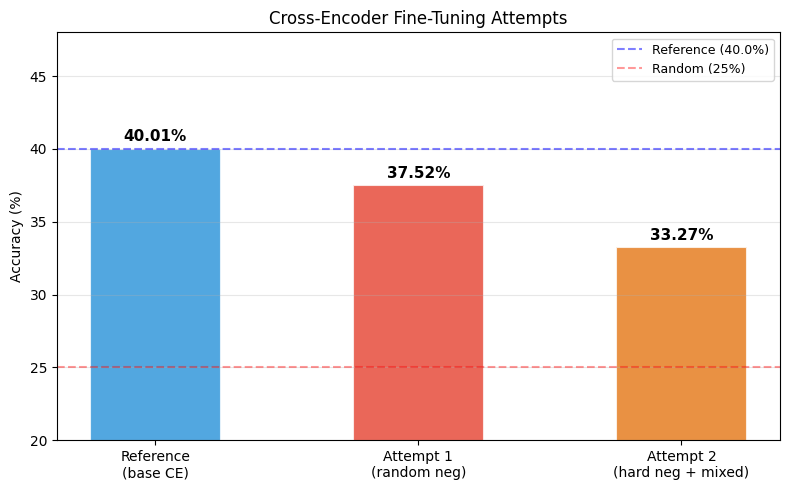

Fine-tuning chart saved


In [10]:
# ─────────────────────────────────────────────
# Chart comparing both fine-tuning attempts
# against reference accuracy
# ─────────────────────────────────────────────

labels = [
    "Reference\n(base CE)",
    "Attempt 1\n(random neg)",
    "Attempt 2\n(hard neg + mixed)",
]
values = [
    reference_acc,
    a1_acc if a1_acc else 0,
    a2_acc if a2_acc else 0,
]
colors = [
    "#3498DB",
    "#E74C3C",
    "#2ECC71" if (a2_acc and a2_acc > reference_acc)
    else "#E67E22",
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors,
               alpha=0.85, edgecolor="white",
               linewidth=1.5, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val:.2f}%",
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.axhline(reference_acc, color='blue', ls='--',
            alpha=0.5,
            label=f'Reference ({reference_acc:.1f}%)')
ax.axhline(25, color='red', ls='--',
            alpha=0.4, label='Random (25%)')

ax.set_ylabel("Accuracy (%)")
ax.set_ylim(20, max(values) + 8)
ax.set_title("Cross-Encoder Fine-Tuning Attempts")
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/finetuning_comparison.png",
            dpi=150)
plt.show()
print("Fine-tuning chart saved")

# Final verification

In [11]:
# ─────────────────────────────────────────────
# Verify all Notebook 06 outputs
# ─────────────────────────────────────────────

print("NOTEBOOK 06 — FINAL VERIFICATION\n")
FT_A1_EVAL_PATH = f"{RESULTS_DIR}/ft_attempt1_eval.json"
FT_A2_EVAL_PATH = f"{RESULTS_DIR}/ft_attempt2_eval.json"
HARD_NEG_PATH = f"{DATA_DIR}/hard_neg_examples.pkl"
checks = [
    (FT_RESULTS_PATH,  "finetuning_results.json",    True),
    (FT_A1_EVAL_PATH,  "ft_attempt1_eval.json",      True),
    (FT_A2_EVAL_PATH,  "ft_attempt2_eval.json",      True),
    (HARD_NEG_PATH,    "hard_neg_examples.pkl",       True),
    (f"{RESULTS_DIR}/finetuning_comparison.png",
     "finetuning_comparison.png", True),
]

all_ok = True
for path, label, required in checks:
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024 if exists else 0
    status = "✅" if exists else "❌"
    if not exists and required:
        all_ok = False
    print(f"  {status} {label:<42} {size:>8.1f} KB")

print(f"\nFine-tuning summary:")
print(f"  Reference (base CE):  {reference_acc:.2f}%")
print(f"  Attempt 1 (random):   "
      f"{f'{a1_acc:.2f}%' if a1_acc else 'N/A'}")
print(f"  Attempt 2 (hard neg): "
      f"{f'{a2_acc:.2f}%' if a2_acc else 'N/A'}")

print()
if all_ok:
    print("All checks passed ✅")
else:
    print("Some checks failed ❌ — review above")

NOTEBOOK 06 — FINAL VERIFICATION

  ✅ finetuning_results.json                         0.7 KB
  ✅ ft_attempt1_eval.json                           0.5 KB
  ✅ ft_attempt2_eval.json                        1423.6 KB
  ✅ hard_neg_examples.pkl                       17739.3 KB
  ✅ finetuning_comparison.png                      53.1 KB

Fine-tuning summary:
  Reference (base CE):  40.01%
  Attempt 1 (random):   37.52%
  Attempt 2 (hard neg): 33.27%

All checks passed ✅
